In [1]:
import numpy as np
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
data = pd.read_csv("climate_data.csv")

In [4]:
X = data.drop(columns=["Energy Consumption"])

y = data ["Energy Consumption"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
scaler = StandardScaler() 
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)

In [8]:
model = Sequential()

In [9]:
model.add (Dense(64, input_dim=X_train.shape[1], activation='relu'))

c:\Users\Avantee Sarve\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.add(Dense(1, activation='linear')) # Use 'sigmoid' or 'softmax' for classification tasks

In [11]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [13]:
# Early stopping to prevent overfitting

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#Train the model
history = model.fit(X_train, y_train, validation_split=0.2, 
                    # Use part of the training set for validation
epochs=50,batch_size=32,

callbacks=[early_stopping])

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3086844.5000 - mae: 1534.2666 - val_loss: 3083650.0000 - val_mae: 1537.3530
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3041387.2500 - mae: 1522.0574 - val_loss: 3016052.2500 - val_mae: 1519.5083
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2950051.5000 - mae: 1498.0383 - val_loss: 2900646.7500 - val_mae: 1489.1479
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2811465.5000 - mae: 1461.3209 - val_loss: 2739887.0000 - val_mae: 1446.3052
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2633687.2500 - mae: 1413.3484 - val_loss: 2546405.5000 - val_mae: 1393.4507
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2427169.5000 - mae: 1355.9326 - val_loss: 2328464.5000 - val_mae: 1331.8170
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2201297.5000 - mae: 1290.7184 - val_loss: 2095451.8750 - val_mae: 1262.9969
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/s

In [14]:
test_loss, test_mae = model.evaluate(X_test, y_test) 
print(f"Test Loss: {test_loss}, Test MAE: {test_mae}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5742.2212 - mae: 57.3356
Test Loss: 5742.22119140625, Test MAE: 57.33561706542969


In [15]:
predictions = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [17]:
print("Predictions:", predictions[:5]) 
print("Actual Values:", y_test[:5].values)

Predictions: [[1106.6158 ]
 [2349.4048 ]
 [ 394.26294]
 [1723.1844 ]
 [2057.1494 ]]
Actual Values: [1148.70560487 2328.94848405  213.59189032 1719.90776768 2114.25192812]


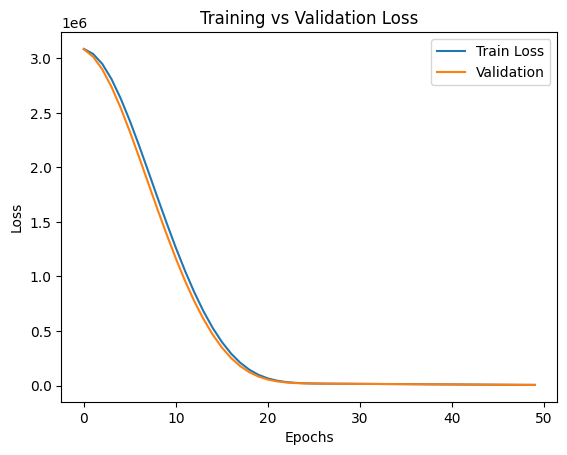

In [19]:
import matplotlib.pyplot as plt

plt.plot (history.history['loss'], label='Train Loss')
plt.plot (history.history['val_loss'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()